**Problem Statement**:
Predict whether a passenger is Satisfied or Neutral/Dissatisfied

**Dataset Summary**

Rows: 129,880

Columns: 24

Target Variable: Satisfaction (classification problem)

**Feature Types**

Categorical:

*   Gender
*   Customer Type


*   Type of Travel
*   Class

*   Satisfaction(target)

Numerical:


*   Age
*   Flight Distance


*   Departure Delay
*   Arrival Delay

*Ordinal Ratings (1–5 scale):*

*   Depature and Arrival Time Conveniece
*   Ease of Online Booking

*   Check-in-Service
*   Online Boarding

*   Gate Location
*   On-board Service

*   Seat Comfort
*   Leg Room

*   Cleanliness
*   Food and Drink

*   In-flight Service
*   In-flight Wifi Service

*   In-flight Entertainment
*   Baggage Handling



In [1]:
#Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#To ignore Warnings
import warnings

warnings.filterwarnings('ignore')

In [3]:
#Uploading Dataset
Air_line_passenger=pd.read_csv("/content/Air line passenger.csv")

In [4]:
#Checking shape
Air_line_passenger.shape

(129880, 24)

In [5]:
#checking first 5 records
Air_line_passenger.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3.0,...,3.0,5.0,2.0,5.0,5.0,5.0,3.0,5.0,5.0,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2.0,...,5.0,4.0,5.0,5.0,3.0,5.0,2.0,5.0,5.0,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4.0,...,3.0,5.0,3.0,5.0,5.0,3.0,4.0,3.0,3.0,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2.0,...,5.0,5.0,5.0,4.0,4.0,5.0,2.0,5.0,5.0,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3.0,...,3.0,4.0,4.0,5.0,4.0,3.0,3.0,3.0,3.0,Satisfied


In [6]:
#checking last 5 records
Air_line_passenger.tail()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4.0,...,5.0,1.0,4.0,4.0,4.0,5.0,4.0,4.0,4.0,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5.0,...,5.0,2.0,5.0,2.0,2.0,4.0,3.0,2.0,5.0,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5.0,...,3.0,3.0,4.0,3.0,3.0,4.0,2.0,3.0,5.0,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4.0,...,4.0,4.0,5.0,3.0,3.0,4.0,5.0,3.0,5.0,Satisfied
129879,129880,Female,20,Returning,Personal,Economy Plus,337,0,0.0,1.0,...,4.0,2.0,4.0,2.0,2.0,2.0,3.0,2.0,1.0,Neutral or Dissatisfied


In [7]:
#checking Datatypes
Air_line_passenger.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129876 non-null  float64
 10  Ease of Online Booking                  1298

In [8]:
#Checking Statistics
Air_line_passenger.describe()

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129876.000000,129876.000000,129876.000000,129876.000000,129869.000000,129869.000000,129865.000000,129865.000000,129869.000000,129869.000000,129863.000000,129863.000000,129863.000000,129863.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057616,2.756883,3.306254,3.252602,2.976938,3.383001,3.441358,3.350864,3.286342,3.204814,3.642123,2.728706,3.358039,3.632058
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526754,1.401752,1.266194,1.350726,1.278538,1.287108,1.319307,1.316217,1.313675,1.329912,1.176702,1.329346,1.334040,1.180049
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [9]:
#Checking Null values
Air_line_passenger.isnull().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,393
Departure and Arrival Time Convenience,4


In [10]:
#Target column Null Values Records Dropping
Air_line_passenger.dropna(subset=['Satisfaction'], inplace=True)

In [11]:
#Filling the Null Values using median
Air_line_passenger['Arrival Delay'].fillna(
Air_line_passenger['Arrival Delay'].median(), inplace=True)

In [12]:
#checking the Null values after filling
Air_line_passenger.isnull().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,0
Departure and Arrival Time Convenience,1


In [13]:
#Rating Columns fill null values with median
rating_cols = [
    'Departure and Arrival Time Convenience',
    'Ease of Online Booking',
    'Check-in Service',
    'Online Boarding',
    'Gate Location',
    'On-board Service',
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink',
    'In-flight Service',
    'In-flight Wifi Service',
    'In-flight Entertainment',
    'Baggage Handling'
]

for col in rating_cols:
    Air_line_passenger[col].fillna(
    Air_line_passenger[col].median(), inplace=True)

In [14]:
#converting Categorical into Numerical Features
rating_cols = [
    'Departure and Arrival Time Convenience',
    'Ease of Online Booking',
    'Check-in Service',
    'Online Boarding',
    'Gate Location',
    'On-board Service',
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink',
    'In-flight Service',
    'In-flight Wifi Service',
    'In-flight Entertainment',
    'Baggage Handling'
]

Air_line_passenger[rating_cols] = Air_line_passenger[rating_cols].astype(int)

In [15]:
#Checking null values for all coulumns after filling
Air_line_passenger.isnull().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,0
Departure and Arrival Time Convenience,0


In [16]:
#Removing the drop column because no use of it
Air_line_passenger.drop(['ID'], axis=1, inplace=True)

In [17]:
Air_line_passenger.nunique()

,0
Gender,2
Age,75
Customer Type,2
Type of Travel,2
Class,3
Flight Distance,3821
Departure Delay,466
Arrival Delay,472
Departure and Arrival Time Convenience,6
Ease of Online Booking,6


In [18]:
#Checking categorical columns unique values
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(Air_line_passenger[col].unique())


Column: Gender
['Male' 'Female']

Column: Customer Type
['First-time' 'Returning']

Column: Type of Travel
['Business' 'Personal']

Column: Class
['Business' 'Economy' 'Economy Plus']

Column: Satisfaction
['Neutral or Dissatisfied' 'Satisfied']


In [19]:
#checking value count of Food and Drink
Air_line_passenger['Food and Drink'].value_counts()

,count
Food and Drink,
4,30560
5,27954
3,27798
2,27378
1,16048
0,132


In [20]:
#checking value count of Satisfaction
Air_line_passenger['Satisfaction'].value_counts()

,count
Satisfaction,
Neutral or Dissatisfied,73449
Satisfied,56421


In [21]:
Air_line_passenger.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,Male,48,First-time,Business,Business,821,2,5.0,3,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,26,39.0,2,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853,0,0.0,4,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,Business,Business,1905,0,0.0,2,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,Returning,Business,Business,3470,0,1.0,3,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [22]:
Air_line_passenger.tail()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
129875,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,3,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,2,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,4,...,4,4,5,3,3,4,5,3,5,Satisfied
129879,Female,20,Returning,Personal,Economy Plus,337,0,0.0,1,3,...,4,2,4,2,2,2,3,2,1,Neutral or Dissatisfied


In [23]:
Air_line_passenger.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129870 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  129870 non-null  object 
 1   Age                                     129870 non-null  int64  
 2   Customer Type                           129870 non-null  object 
 3   Type of Travel                          129870 non-null  object 
 4   Class                                   129870 non-null  object 
 5   Flight Distance                         129870 non-null  int64  
 6   Departure Delay                         129870 non-null  int64  
 7   Arrival Delay                           129870 non-null  float64
 8   Departure and Arrival Time Convenience  129870 non-null  int64  
 9   Ease of Online Booking                  129870 non-null  int64  
 10  Check-in Service                        129870 no

In [24]:
Air_line_passenger

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,Male,48,First-time,Business,Business,821,2,5.0,3,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,26,39.0,2,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853,0,0.0,4,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,Business,Business,1905,0,0.0,2,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,Returning,Business,Business,3470,0,1.0,3,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,3,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,2,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,4,...,4,4,5,3,3,4,5,3,5,Satisfied


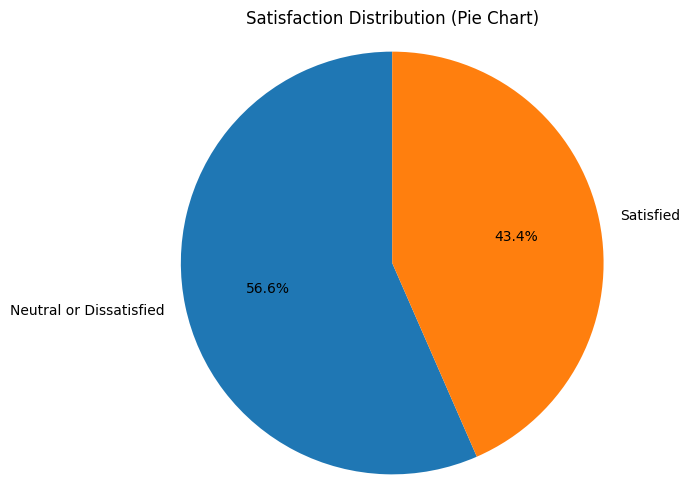

In [25]:
#Satisfaction Distribution using Pie Chart
satisfaction_counts = Air_line_passenger['Satisfaction'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    satisfaction_counts,
    labels=satisfaction_counts.index,
    autopct='%1.1f%%',   # Shows percentage
    startangle=90
)
plt.title("Satisfaction Distribution (Pie Chart)")
plt.axis('equal')
plt.show()

Observation: Here Neutral or Dissatisfied have more portion then Satisfied.

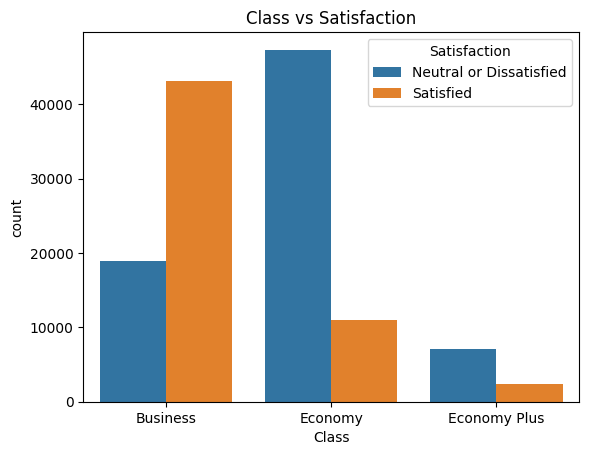

In [26]:
#Checking Class and Satisfaction Relation
sns.countplot(x='Class', hue='Satisfaction', data=Air_line_passenger)
plt.title("Class vs Satisfaction")
plt.show()

Observation: Economy class(more than 40000) passengers were rate for Neutral or Dissatisfied, Business class(more than 40000) passengers were rate for satisfied, Economy Plus class (under 10000) passengers were rate for neutral or Dissatisfied

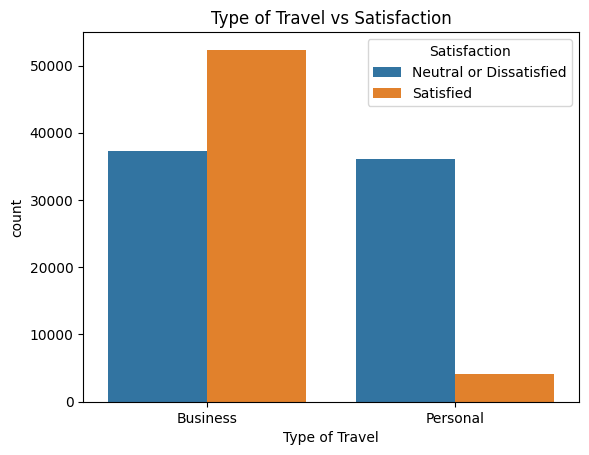

In [27]:
#Type of Travel Vs Satisfaction
sns.countplot(x='Type of Travel', hue='Satisfaction', data=Air_line_passenger)
plt.title("Type of Travel vs Satisfaction")
plt.show()

Observation: Business Type of Travelers are satisfied more than 50000 and Personal Type of Travelers are Neutral or Dissatisfied

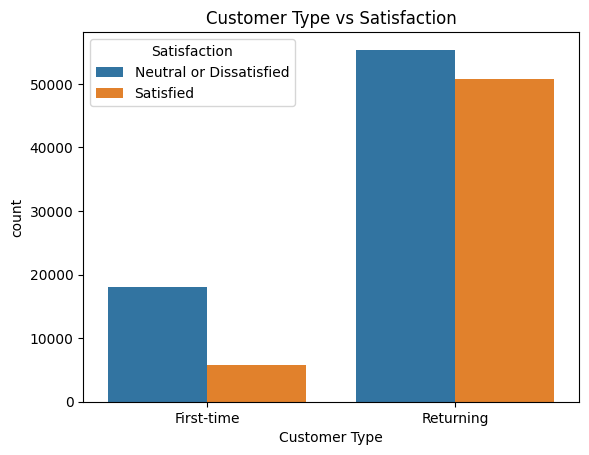

In [28]:
#
sns.countplot(x='Customer Type', hue='Satisfaction', data=Air_line_passenger)
plt.title("Customer Type vs Satisfaction")
plt.show()

Observation: Returning Customer Type people were more Satisfied.

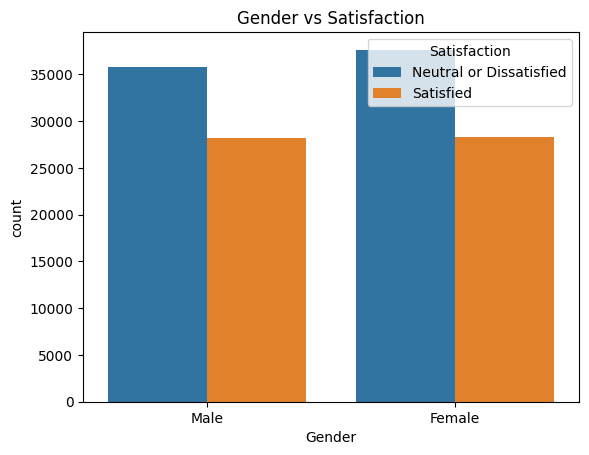

In [29]:
sns.countplot(x='Gender', hue='Satisfaction', data=Air_line_passenger)
plt.title("Gender vs Satisfaction")
plt.show()

Observation: Female Gender were satisfied then Male Gender

Observation: Flight distance is right-skewed, meaning most passengers travel short distances, with few long-distance flights.

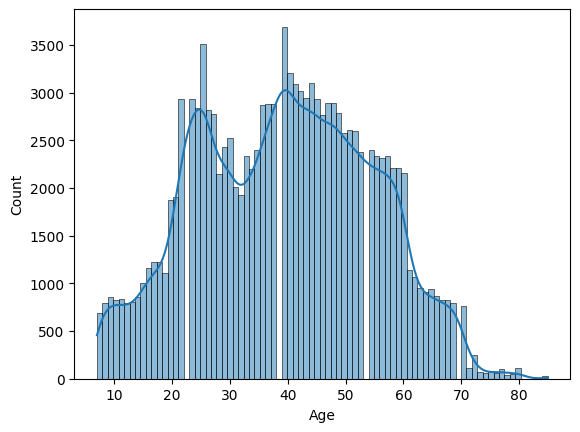

In [30]:
sns.histplot(Air_line_passenger['Age'], kde=True)
plt.show()

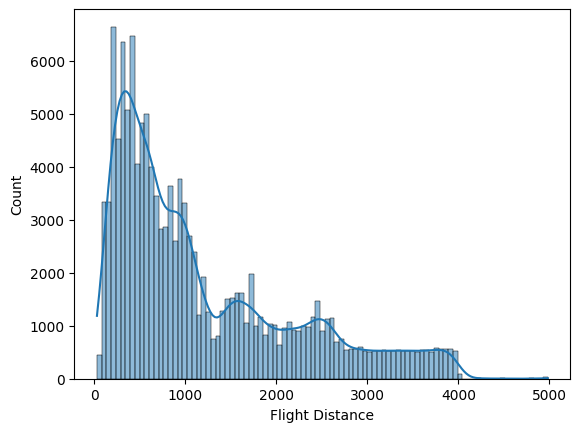

In [31]:
sns.histplot(Air_line_passenger['Flight Distance'], kde=True)
plt.show()

Observation: Age has left-skewed and passengers were between the age of 10-65.

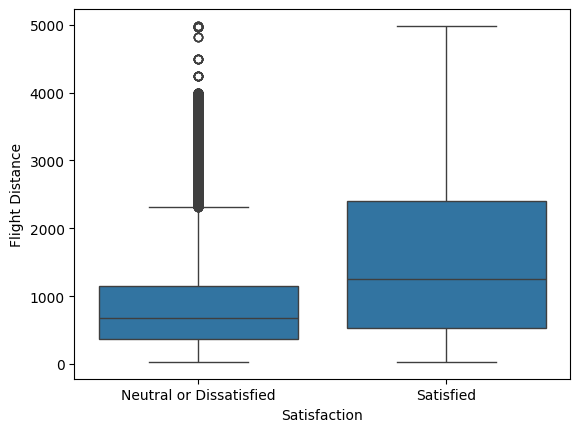

In [32]:
sns.boxplot(x='Satisfaction', y='Flight Distance', data=Air_line_passenger)
plt.show()

Observation: Flight Distance has more outliers to the Neutral or Dissatisfied, More Distance Passengers are  highly Satisfied

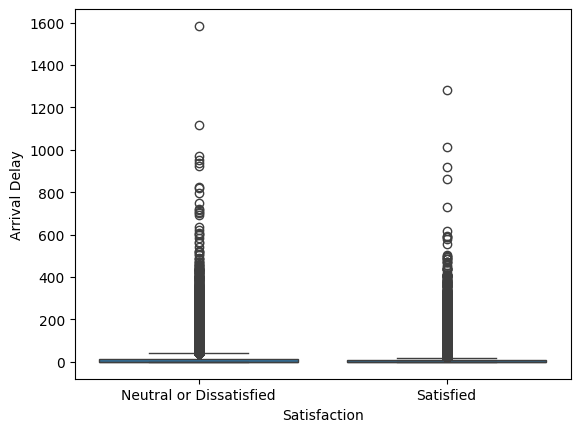

In [33]:
sns.boxplot(x='Satisfaction', y='Arrival Delay', data=Air_line_passenger)
plt.show()

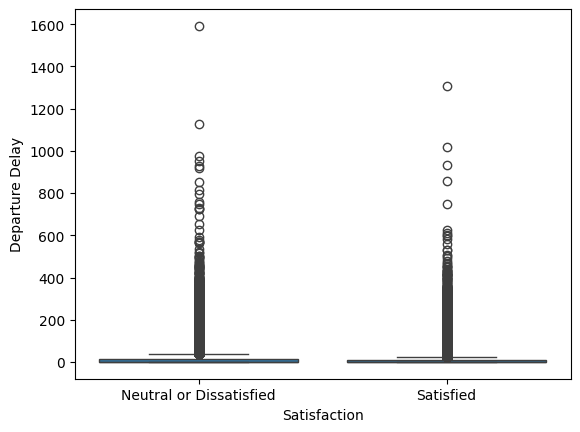

In [34]:
sns.boxplot(x='Satisfaction', y='Departure Delay', data=Air_line_passenger)
plt.show()

Observation: Departure Delay has more outliers to Neutral or Dissatisfied.

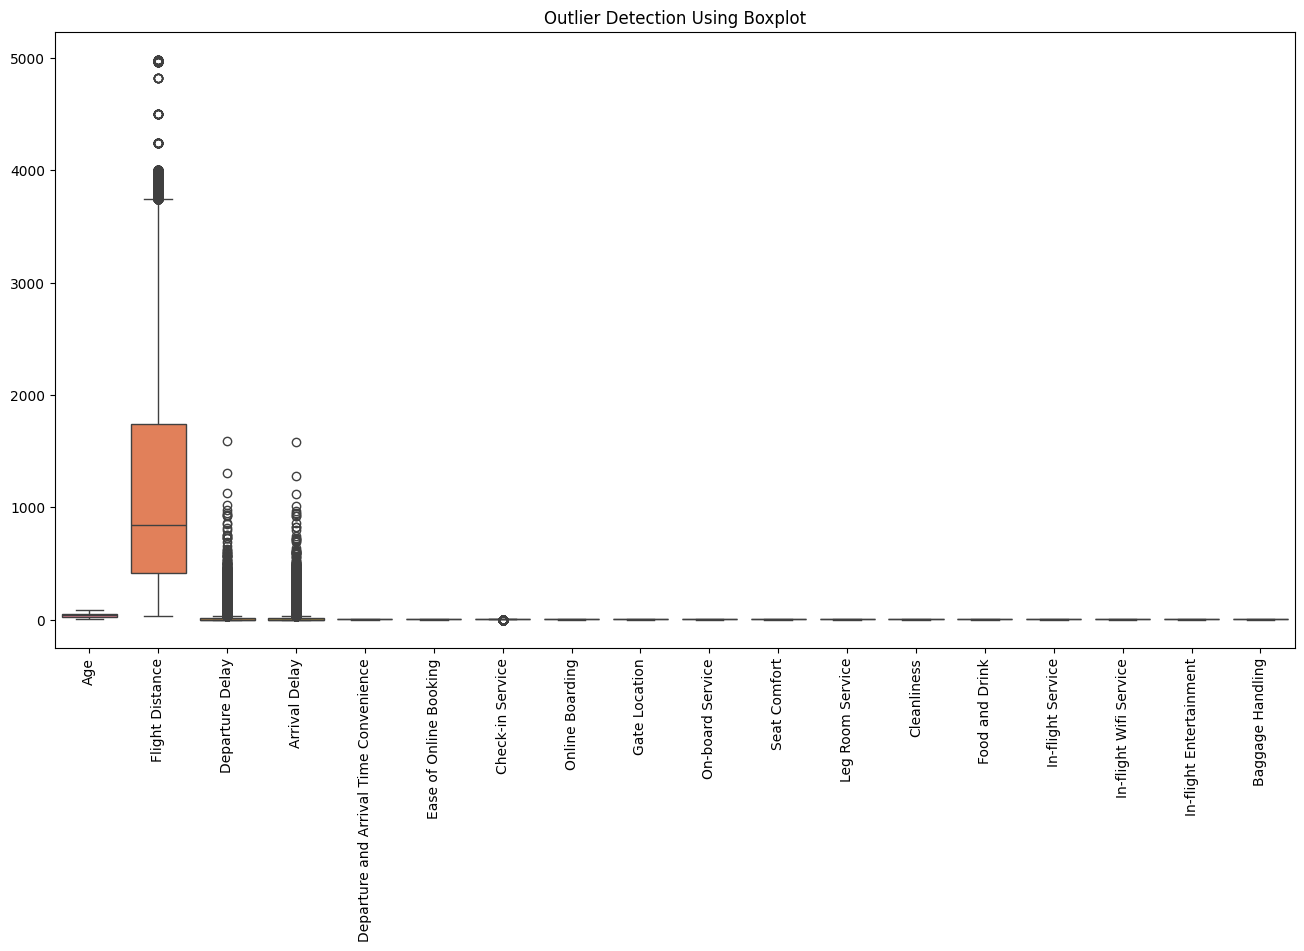

In [35]:
#checking the outliers in one graph
#numeric features
df_numeric = Air_line_passenger.select_dtypes(include=[np.number])
plt.figure(figsize=(16,8))
sns.boxplot(data=df_numeric)

plt.xticks(rotation=90)  # rotate feature names
plt.title("Outlier Detection Using Boxplot")
plt.show()

Observation: Flight Distance , Departure Delay and Arrival Delay have more outliers and we need handle with this outliers.

In [36]:
cols = ['Flight Distance', 'Departure Delay', 'Arrival Delay']

for col in cols:
    Q1 = Air_line_passenger[col].quantile(0.25)
    Q3 = Air_line_passenger[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping
    Air_line_passenger[col] = np.where(Air_line_passenger[col] < lower_bound, lower_bound, Air_line_passenger[col])
    Air_line_passenger[col] = np.where(Air_line_passenger[col] > upper_bound, upper_bound, Air_line_passenger[col])

print("Outliers handled using capping")

Outliers handled using capping


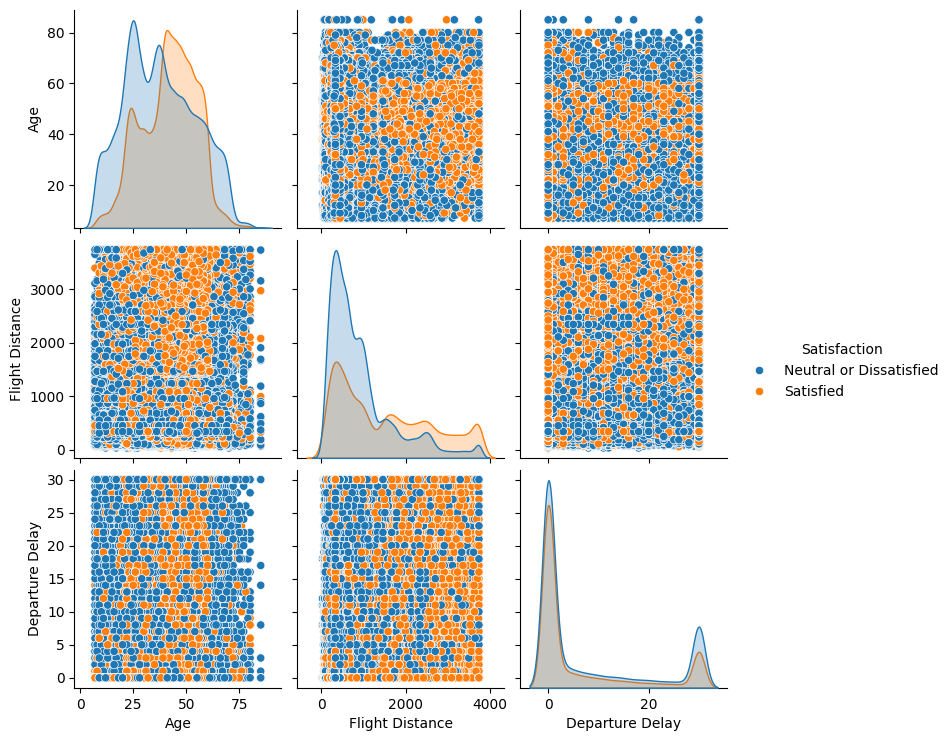

In [37]:
sns.pairplot(Air_line_passenger[['Age','Flight Distance','Departure Delay','Satisfaction']], hue='Satisfaction')
plt.show()

Observation:The age distribution shows that most passengers fall between middle age groups (around 30–60), with similar patterns across satisfaction categories, indicating age is not a strong differentiator of satisfaction.
The scatter plots suggest no clear linear relationship between age and other variables, implying age alone does not significantly influence customer satisfaction or travel behavior.

In [38]:
print(Air_line_passenger['Satisfaction'].value_counts())

Satisfaction
Neutral or Dissatisfied    73449
Satisfied                  56421
Name: count, dtype: int64


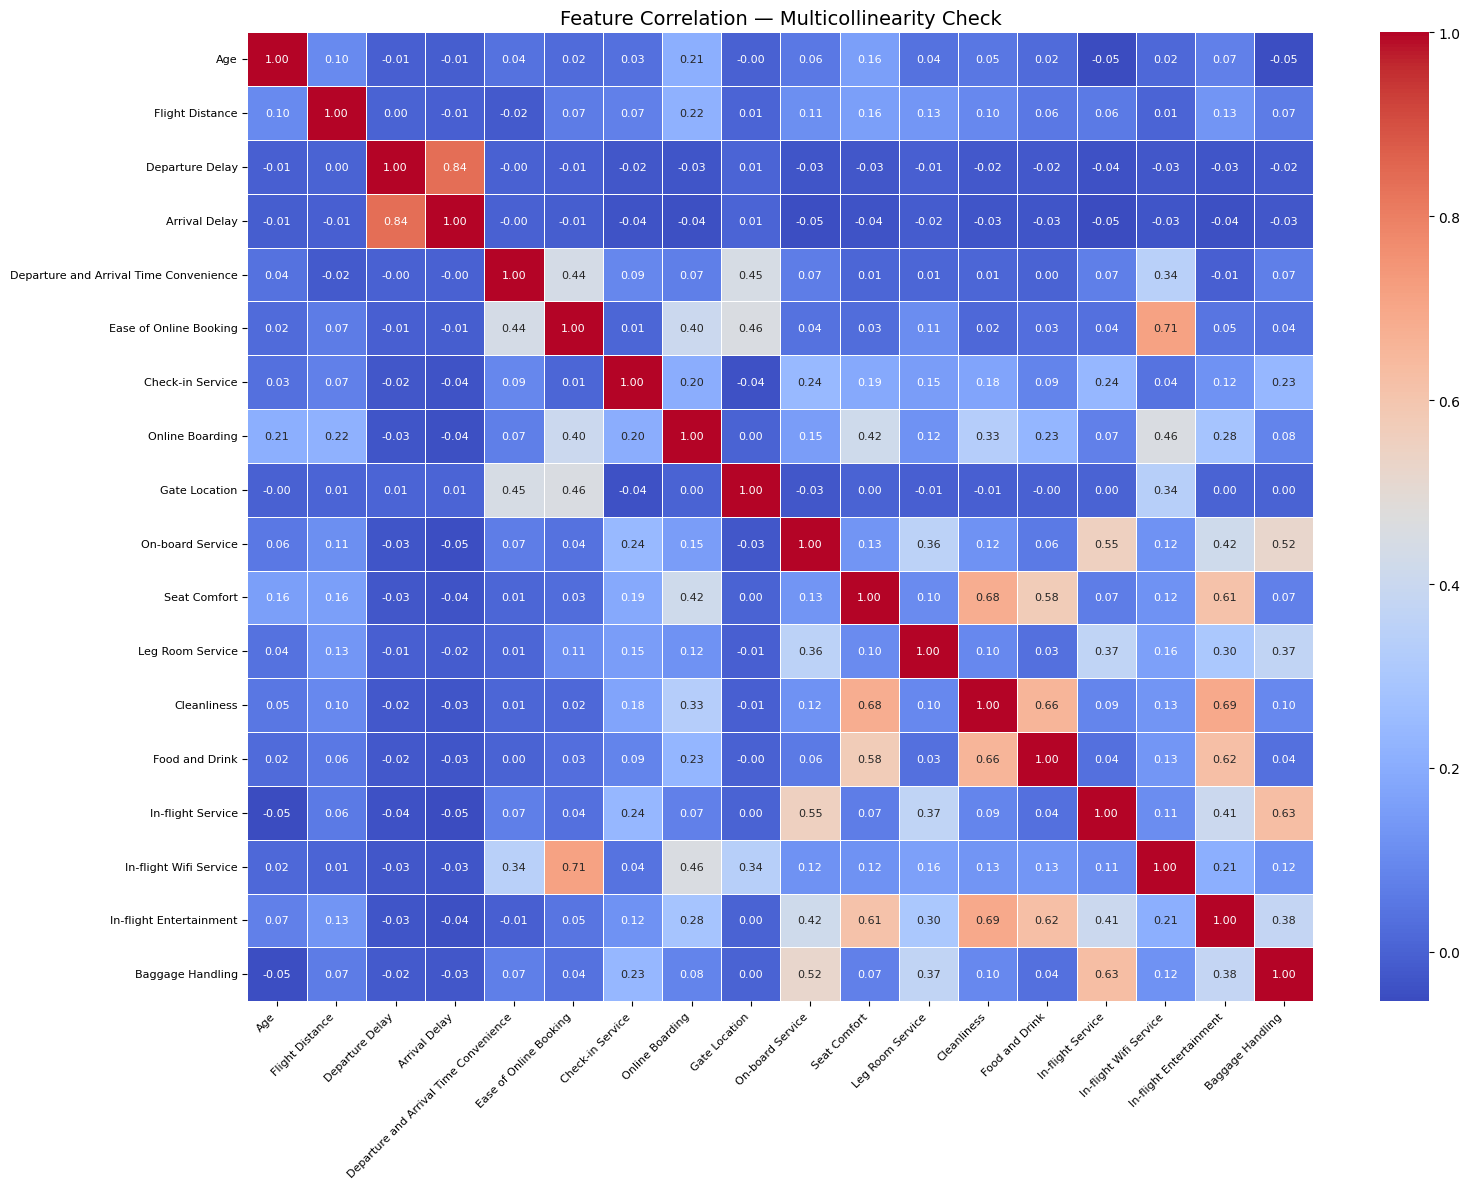

In [40]:
# Multicollinearity Check — Correlation Heatmap
df_numeric = Air_line_passenger.select_dtypes(include=[np.number])

# Drop target if it exists
if 'Satisfaction' in df_numeric.columns:
    df_numeric = df_numeric.drop('Satisfaction', axis=1)

plt.figure(figsize=(16, 12))
sns.heatmap(
    df_numeric.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Feature Correlation — Multicollinearity Check", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

Observation: Satisfaction is positively correlated with service-related features such as seat comfort, in-flight entertainment, food & drink, and online boarding, indicating that better service quality strongly increases customer satisfaction.
Departure delay and arrival delay are highly correlated with each other but show weak or negative correlation with satisfaction, suggesting delays impact experience but are not the primary drivers compared to service factors.

In [41]:
Air_line_passenger.columns

Index(['Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class',
       'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction'],
      dtype='object')

In [42]:
#Feature selection
Air_line_passenger['Total Delay'] = Air_line_passenger['Departure Delay'] + Air_line_passenger['Arrival Delay']
Air_line_passenger.drop(['Departure Delay', 'Arrival Delay'], axis=1, inplace=True)

***Encoding***




In [43]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder

# 1. Encode target
le = LabelEncoder()
Air_line_passenger['Satisfaction'] = le.fit_transform(Air_line_passenger['Satisfaction'])

# 2. Ordinal encode 'Class'
oe = OrdinalEncoder(categories=[['Economy', 'Economy Plus', 'Business']])
Air_line_passenger['Class'] = oe.fit_transform(Air_line_passenger[['Class']])

# 3. One-hot encode nominal columns
nominal_cols = ['Gender', 'Customer Type', 'Type of Travel']
Air_line_passenger = pd.get_dummies(Air_line_passenger, columns=nominal_cols, drop_first=True, dtype=int)





***Train & Test Data Splitting***

In [44]:
Air_line_passenger
Air_line_passenger.columns

Index(['Age', 'Class', 'Flight Distance',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction',
       'Total Delay', 'Gender_Male', 'Customer Type_Returning',
       'Type of Travel_Personal'],
      dtype='object')

In [45]:
Air_line_passenger.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129870 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Age                                     129870 non-null  int64  
 1   Class                                   129870 non-null  float64
 2   Flight Distance                         129870 non-null  float64
 3   Departure and Arrival Time Convenience  129870 non-null  int64  
 4   Ease of Online Booking                  129870 non-null  int64  
 5   Check-in Service                        129870 non-null  int64  
 6   Online Boarding                         129870 non-null  int64  
 7   Gate Location                           129870 non-null  int64  
 8   On-board Service                        129870 non-null  int64  
 9   Seat Comfort                            129870 non-null  int64  
 10  Leg Room Service                        129870 no

In [46]:
#Defining Features and Target
X = Air_line_passenger.drop('Satisfaction', axis=1)
y = Air_line_passenger['Satisfaction']

In [47]:
Air_line_passenger.columns

Index(['Age', 'Class', 'Flight Distance',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction',
       'Total Delay', 'Gender_Male', 'Customer Type_Returning',
       'Type of Travel_Personal'],
      dtype='object')

In [48]:
print(Air_line_passenger['Class'].head())
print(Air_line_passenger['Class'].dtype)

0    2.0
1    2.0
2    2.0
3    2.0
4    2.0
Name: Class, dtype: float64
float64


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
X_train.shape, X_test.shape

((103896, 21), (25974, 21))

80% training, 20% testing

In [51]:
cols = X_train.select_dtypes(include='object').columns.tolist()
print(cols)

[]


***Random Forest***

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [74]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [75]:
y_pred_rf = rf.predict(X_test)

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9640794640794641

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     14721
           1       0.97      0.94      0.96     11253

    accuracy                           0.96     25974
   macro avg       0.97      0.96      0.96     25974
weighted avg       0.96      0.96      0.96     25974


Confusion Matrix:
 [[14432   289]
 [  644 10609]]


In [77]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9640794640794641


In [78]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

CV Accuracy: 0.9624 ± 0.0006


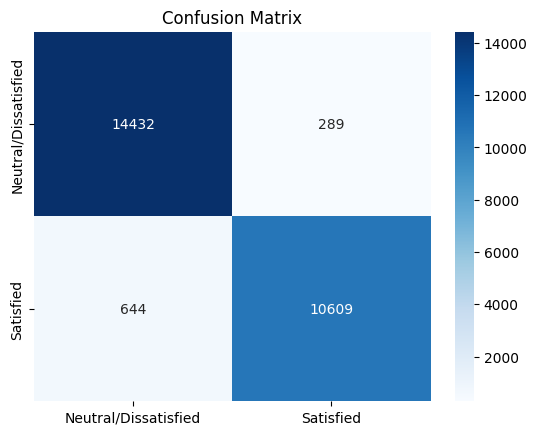

ROC-AUC: 0.9942124318026361


In [79]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral/Dissatisfied', 'Satisfied'],
            yticklabels=['Neutral/Dissatisfied', 'Satisfied'])
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import roc_auc_score
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

In [80]:
rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=15,           # control overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [81]:
importance = rf.feature_importances_

imp_Air_line_passenger = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance',ascending=True)

print(imp_Air_line_passenger)

                                   Feature  Importance
18                             Gender_Male    0.002414
17                             Total Delay    0.007220
12                          Food and Drink    0.008739
7                            Gate Location    0.011815
3   Departure and Arrival Time Convenience    0.013638
5                         Check-in Service    0.019577
13                       In-flight Service    0.019975
0                                      Age    0.022861
11                             Cleanliness    0.023763
16                        Baggage Handling    0.024204
8                         On-board Service    0.025068
2                          Flight Distance    0.028516
10                        Leg Room Service    0.037332
19                 Customer Type_Returning    0.038164
4                   Ease of Online Booking    0.038355
9                             Seat Comfort    0.046991
15                 In-flight Entertainment    0.057072
1         

In [82]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 0.9722703472703472
Test Accuracy: 0.9606529606529607


Random Forest is an ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting. It provides better generalization and feature importance insights compared to a single decision tree

I select Random Forest Because, compare to other model it have high accuracy and reduce overfitting, better generalization and stable performance

In [83]:
X.columns

Index(['Age', 'Class', 'Flight Distance',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Total Delay',
       'Gender_Male', 'Customer Type_Returning', 'Type of Travel_Personal'],
      dtype='object')

In [84]:
X_train.columns

Index(['Age', 'Class', 'Flight Distance',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Total Delay',
       'Gender_Male', 'Customer Type_Returning', 'Type of Travel_Personal'],
      dtype='object')

***Conclusion***

Among all models, Random Forest was selected as the final model due to its high accuracy and ability to reduce overfitting compared to Decision Tree. It provided better generalization and stable performance.

In [85]:
import joblib

joblib.dump(rf, "model.pkl")
print("✅ Model saved → model.pkl")
print("   Features the model expects:", list(rf.feature_names_in_))

✅ Model saved → model.pkl
   Features the model expects: ['Age', 'Class', 'Flight Distance', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Total Delay', 'Gender_Male', 'Customer Type_Returning', 'Type of Travel_Personal']


In [86]:
from google.colab import files

files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***Validations***

In [88]:
import pandas as pd
import joblib

model = joblib.load("model.pkl")

CLASS_MAP = {
    'Economy': 0,
    'Economy Plus': 1,
    'Business': 2
}

def predict_passenger(input_dict, model, class_map=CLASS_MAP):
    # Step 1 — dict → DataFrame (one row)
    input_df = pd.DataFrame([input_dict])

    # Step 2 — Encode 'Class' (same ordinal order as training)
    input_df['Class'] = input_df['Class'].map(class_map)

    # Step 3 — One-hot encode nominal columns
    input_df = pd.get_dummies(input_df)

    # Step 4 — Align to training columns
    #           Missing columns (e.g. Gender_Male=0) are filled with 0
    input_df = input_df.reindex(columns=model.feature_names_in_, fill_value=0)

    # Step 5 — Predict
    pred = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0]

    label = "Satisfied" if pred == 1 else "Neutral or Dissatisfied"
    print(f"  Prediction  : {pred} → {label}")
    print(f"  Probability : Neutral/Dissatisfied = {prob[0]:.3f} | "
          f"Satisfied = {prob[1]:.3f}")
    return pred, prob


In [92]:
print("=" * 55)
print("VALIDATION 1")
print("Profile : Business | High ratings | Returning | Male")
print("Expected: Satisfied")
print("=" * 55)

input_v1 = {
    'Age': 35,
    'Class': 'Business',
    'Flight Distance': 1500,
    'Departure and Arrival Time Convenience': 5,
    'Ease of Online Booking': 5,
    'Check-in Service': 5,
    'Online Boarding': 5,
    'Gate Location': 4,
    'On-board Service': 5,
    'Seat Comfort': 5,
    'Leg Room Service': 5,
    'Cleanliness': 5,
    'Food and Drink': 4,
    'In-flight Service': 5,
    'In-flight Wifi Service': 4,
    'In-flight Entertainment': 5,
    'Baggage Handling': 5,
    'Total Delay': 0,
    'Gender': 'Male',
    'Customer Type': 'Returning',
    'Type of Travel': 'Business'
}

pred_v1, prob_v1 = predict_passenger(input_v1, model)

VALIDATION 1
Profile : Business | High ratings | Returning | Male
Expected: Satisfied
  Prediction  : 1 → Satisfied
  Probability : Neutral/Dissatisfied = 0.018 | Satisfied = 0.982


In [94]:
print("=" * 55)
print("VALIDATION 2")
print("Profile : Economy | Low ratings | First-time | Female")
print("Expected: Neutral or Dissatisfied")
print("=" * 55)

input_v2 = {
    'Age': 25,
    'Class': 'Economy',
    'Flight Distance': 212,
    'Departure and Arrival Time Convenience': 2,
    'Ease of Online Booking': 3,
    'Check-in Service': 1,
    'Online Boarding': 3,
    'Gate Location': 4,
    'On-board Service': 1,
    'Seat Comfort': 3,
    'Leg Room Service': 2,
    'Cleanliness': 4,
    'Food and Drink': 4,
    'In-flight Service': 4,
    'In-flight Wifi Service': 3,
    'In-flight Entertainment': 4,
    'Baggage Handling': 3,
    'Total Delay': 11,
    'Gender': 'Female',
    'Customer Type': 'First-time',
    'Type of Travel': 'Business'
}

pred_v2, prob_v2 = predict_passenger(input_v2, model)

VALIDATION 2
Profile : Economy | Low ratings | First-time | Female
Expected: Neutral or Dissatisfied
  Prediction  : 0 → Neutral or Dissatisfied
  Probability : Neutral/Dissatisfied = 0.998 | Satisfied = 0.002


In [95]:
print("=" * 55)
print("VALIDATION 3")
print("Profile : Economy | HIGH ratings | First-time | Female")
print("Expected: Borderline")
print("=" * 55)

input_v3 = {
    'Age': 25,
    'Class': 'Economy',
    'Flight Distance': 212,
    'Departure and Arrival Time Convenience': 2,
    'Ease of Online Booking': 5,
    'Check-in Service': 5,
    'Online Boarding': 5,
    'Gate Location': 4,
    'On-board Service': 5,
    'Seat Comfort': 3,
    'Leg Room Service': 5,
    'Cleanliness': 4,
    'Food and Drink': 5,
    'In-flight Service': 4,
    'In-flight Wifi Service': 5,
    'In-flight Entertainment': 5,
    'Baggage Handling': 3,
    'Total Delay': 11,
    'Gender': 'Female',
    'Customer Type': 'First-time',
    'Type of Travel': 'Business'
}

pred_v3, prob_v3 = predict_passenger(input_v3, model)

VALIDATION 3
Profile : Economy | HIGH ratings | First-time | Female
Expected: Borderline
  Prediction  : 1 → Satisfied
  Probability : Neutral/Dissatisfied = 0.034 | Satisfied = 0.966


In [96]:
print("=" * 55)
print("VALIDATION 4")
print("Profile : Business | High ratings | Returning | Male")
print("Expected: Satisfied")
print("=" * 55)

input_v4 = {
    'Age': 40,
    'Class': 'Business',
    'Flight Distance': 1200,
    'Departure and Arrival Time Convenience': 4,
    'Ease of Online Booking': 4,
    'Check-in Service': 5,
    'Online Boarding': 5,
    'Gate Location': 3,
    'On-board Service': 5,
    'Seat Comfort': 5,
    'Leg Room Service': 4,
    'Cleanliness': 5,
    'Food and Drink': 4,
    'In-flight Service': 5,
    'In-flight Wifi Service': 4,
    'In-flight Entertainment': 5,
    'Baggage Handling': 5,
    'Total Delay': 0,
    'Gender': 'Male',
    'Customer Type': 'Returning',
    'Type of Travel': 'Business'
}

pred_v4, prob_v4 = predict_passenger(input_v4, model)

VALIDATION 4
Profile : Business | High ratings | Returning | Male
Expected: Satisfied
  Prediction  : 1 → Satisfied
  Probability : Neutral/Dissatisfied = 0.079 | Satisfied = 0.921


In [97]:
print("=" * 55)
print("VALIDATION 5")
print("Profile : Business | Mixed ratings | Returning | Male")
print("Expected: Possibly Satisfied")
print("=" * 55)

input_v5 = {
    'Age': 35,
    'Class': 'Business',
    'Flight Distance': 1500,
    'Departure and Arrival Time Convenience': 5,
    'Ease of Online Booking': 5,
    'Check-in Service': 5,
    'Online Boarding': 1,           # low
    'Gate Location': 4,
    'On-board Service': 5,
    'Seat Comfort': 5,
    'Leg Room Service': 5,
    'Cleanliness': 5,
    'Food and Drink': 4,
    'In-flight Service': 5,
    'In-flight Wifi Service': 1,    # low
    'In-flight Entertainment': 2,   # low
    'Baggage Handling': 1,          # low
    'Total Delay': 0,
    'Gender': 'Male',
    'Customer Type': 'Returning',
    'Type of Travel': 'Business'
}

pred_v5, prob_v5 = predict_passenger(input_v5, model)

VALIDATION 5
Profile : Business | Mixed ratings | Returning | Male
Expected: Possibly Satisfied
  Prediction  : 1 → Satisfied
  Probability : Neutral/Dissatisfied = 0.332 | Satisfied = 0.668


In [98]:
label_map = {0: "Neutral/Dissatisfied", 1: "Satisfied"}

print()
print("=" * 60)
print("           VALIDATION SUMMARY — ALL RESULTS")
print("=" * 60)

cases = [
    ("V1 — Business | High ratings  | Returning | Male  ", pred_v1, prob_v1),
    ("V2 — Economy  | Low ratings   | First-time| Female", pred_v2, prob_v2),
    ("V3 — Economy  | HIGH ratings  | First-time| Female", pred_v3, prob_v3),
    ("V4 — Business | High ratings  | Returning | Male  ", pred_v4, prob_v4),
    ("V5 — Business | Mixed ratings | Returning | Male  ", pred_v5, prob_v5),
]

print(f"\n  {'Profile':<45} {'Result':<25} {'Confidence'}")
print(f"  {'-'*45} {'-'*25} {'-'*10}")

for name, pred, prob in cases:
    result = label_map[pred]
    conf   = max(prob)
    print(f"  {name:<45} {result:<25} {conf:.1%}")


           VALIDATION SUMMARY — ALL RESULTS

  Profile                                       Result                    Confidence
  --------------------------------------------- ------------------------- ----------
  V1 — Business | High ratings  | Returning | Male   Satisfied                 98.2%
  V2 — Economy  | Low ratings   | First-time| Female Neutral/Dissatisfied      99.8%
  V3 — Economy  | HIGH ratings  | First-time| Female Satisfied                 96.6%
  V4 — Business | High ratings  | Returning | Male   Satisfied                 92.1%
  V5 — Business | Mixed ratings | Returning | Male   Satisfied                 66.8%
